# Twitter Sentiment Analysis using RNN (LSTM)

**Overview:** This project performs sentiment analysis on a dataset of Twitter posts using Recurrent Neural Networks (RNN). The goal is to classify the sentiment of tweets as positive, negative, or neutral based on the text data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Download necessary NLTK datasets
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/psundara/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/psundara/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Part 1: Data Processing
### 1. Load the Dataset & Basic Cleaning

In [2]:
# Load dataset
df = pd.read_csv('data/twitter_training.csv', header=None)
df.columns = ['id', 'entity', 'sentiment', 'text']
# ------------------------------------------

# Display first few rows
display(df.head())

# Check for missing values and handle them
print("Missing values before cleaning:\n", df.isnull().sum())
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()
print(f"Data shape after removing missing values and duplicates: {df.shape}")

,id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


Missing values before cleaning:
 id             0
entity         0
sentiment      0
text         686
dtype: int64
Data shape after removing missing values and duplicates: (71656, 4)


### 2. Text Cleaning & Preprocessing
Removing URLs, mentions, hashtags, special characters, applying lowercasing, stop word removal, and lemmatization.

In [3]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_tweet(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove user @ references and '#' from tweet
    text = re.sub(r'\@\w+|\#','', text)
    # Remove special characters, numbers, punctuations
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Tokenization (simple split)
    tokens = text.split()
    # Remove stop words and lemmatize
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(cleaned_tokens)

# Apply cleaning function to the text column
df['cleaned_text'] = df['text'].apply(clean_tweet)

display(df[['text', 'cleaned_text']].head())

,text,cleaned_text
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,im getting borderland murder


## Part 2: Exploratory Data Analysis (EDA)
### 1. Distribution of Sentiments

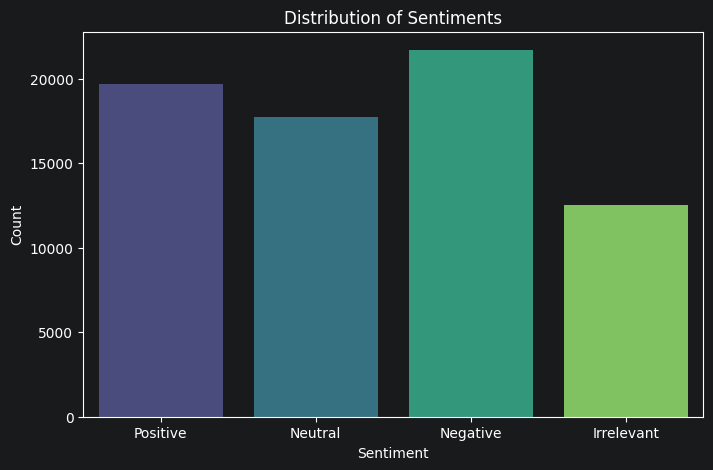

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=df, palette='viridis', hue='sentiment')
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

### 2. Word Clouds & Tweet Length Analysis

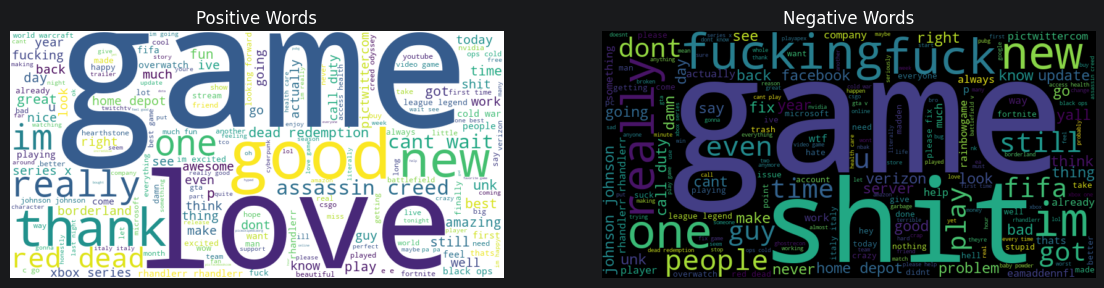

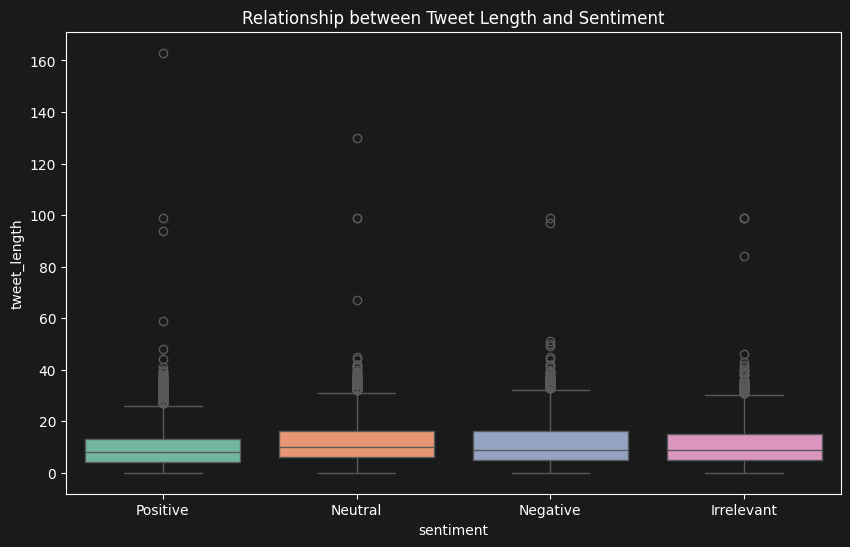

In [9]:
# Word Cloud for Positive Tweets
positive_text = ' '.join(df[df['sentiment'] == 'Positive']['cleaned_text'])
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

# Word Cloud for Negative Tweets
negative_text = ' '.join(df[df['sentiment'] == 'Negative']['cleaned_text'])
if negative_text.strip(): # Check if there are negative words
    wordcloud_neg = WordCloud(width=800, height=400, background_color='black').generate(negative_text)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.title('Positive Words')
plt.axis('off')

if negative_text.strip():
    plt.subplot(1, 2, 2)
    plt.imshow(wordcloud_neg, interpolation='bilinear')
    plt.title('Negative Words')
    plt.axis('off')
plt.show()

# Tweet Length Analysis
df['tweet_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment', y='tweet_length', data=df, palette='Set2', hue='sentiment')
plt.title('Relationship between Tweet Length and Sentiment')
plt.show()

## Part 3: Feature Engineering & Building the RNN Model
### 1. Tokenization and Encoding

In [11]:
# Parameters
MAX_WORDS = 5000
MAX_LEN = 100

# Tokenize text
tokenizer = Tokenizer(num_words=MAX_WORDS, lower=True)
tokenizer.fit_on_texts(df['cleaned_text'].values)
word_index = tokenizer.word_index
print(f'Found {len(word_index)} unique tokens.')

# Convert text to sequences and pad them
X = tokenizer.texts_to_sequences(df['cleaned_text'].values)
X = pad_sequences(X, maxlen=MAX_LEN)

# Encode labels
encoder = LabelEncoder()
Y = encoder.fit_transform(df['sentiment'])
# Convert integer labels to categorical (one-hot encoding)
Y = tf.keras.utils.to_categorical(Y, num_classes=4)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Found 34658 unique tokens.
X_train shape: (57324, 100)
X_test shape: (14332, 100)


### 2. Model Architecture & Implementation (LSTM)

In [14]:
# Define model architecture
model = Sequential()
model.add(Embedding(input_dim=MAX_WORDS, output_dim=128))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(4, activation='softmax')) # 4 classes: positive, negative, neutral, irrelavent

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.build(input_shape=(None, MAX_LEN))
model.summary()

# Early stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model (Adjust epochs and batch_size based on your dataset)
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100)            │        91,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 732,004 (2.79 MB)

 Trainable params: 732,004 (2.79 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 122s 134ms/step - accuracy: 0.5751 - loss: 1.0159 - val_accuracy: 0.6569 - val_loss: 0.8500
Epoch 2/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 119s 133ms/step - accuracy: 0.7009 - loss: 0.7558 - val_accuracy: 0.7067 - val_loss: 0.7366
Epoch 3/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 123s 137ms/step - accuracy: 0.7514 - loss: 0.6329 - val_accuracy: 0.7404 - val_loss: 0.6744
Epoch 4/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 118s 132ms/step - accuracy: 0.7890 - loss: 0.5463 - val_accuracy: 0.7583 - val_loss: 0.6398
Epoch 5/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 120s 134ms/step - accuracy: 0.8113 - loss: 0.4883 - val_accuracy: 0.7687 - val_loss: 0.6237
Epoch 6/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 122s 137ms/step - accuracy: 0.8268 - loss: 0.4441 - val_accuracy: 0.7767 - val_loss: 0.6113
Epoch 7/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 117s 131ms/step - accuracy: 0.8426 - loss: 0.4048 - val_accuracy: 0.7843 - val_loss: 0.6025
Epoch 8/10
896/896 ━━━━━━━━━━━━━━━━━━━━ 116s 129ms/step - accuracy: 0.8548 -

### 3. Evaluation & Learning Curves

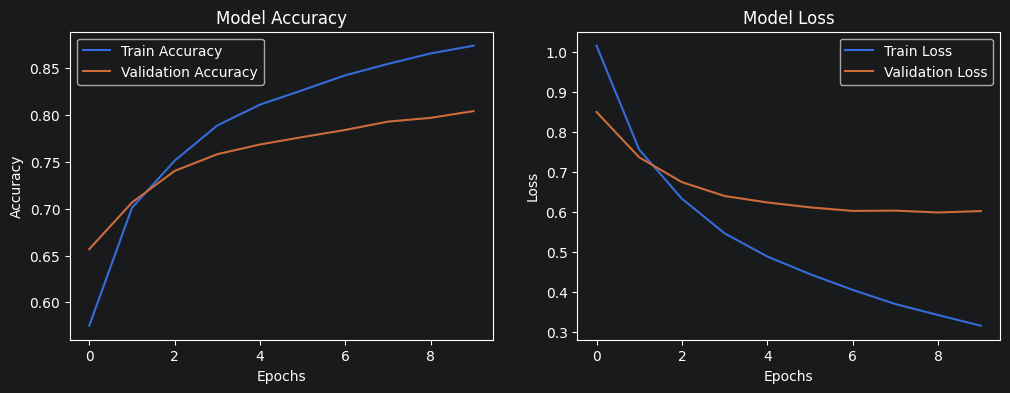

448/448 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step
Classification Report:

              precision    recall  f1-score   support

  Irrelevant       0.82      0.71      0.76      2529
    Negative       0.84      0.85      0.84      4383
     Neutral       0.82      0.74      0.78      3543
    Positive       0.73      0.85      0.79      3877

    accuracy                           0.80     14332
   macro avg       0.80      0.79      0.79     14332
weighted avg       0.80      0.80      0.80     14332



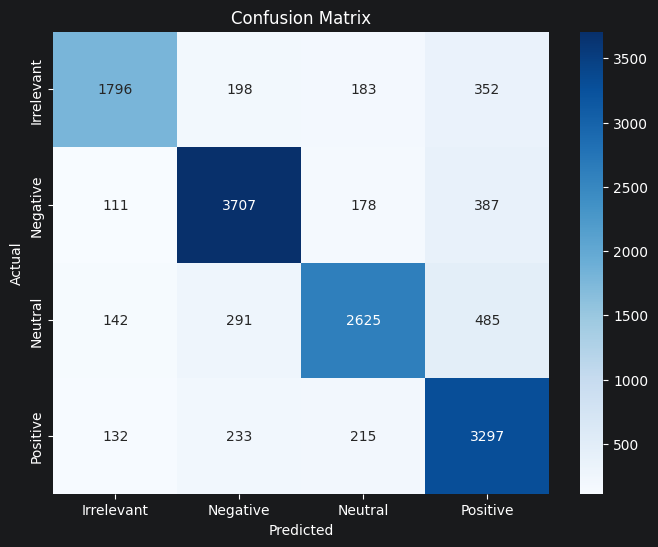

In [15]:
# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Predictions and Metrics
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("Classification Report:\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 4. Model Improvement (Hyperparameter Tuning & Advanced Architecture)
To improve model performance, we can introduce a more complex architecture with `BatchNormalization`, stacked LSTM layers, and adjusted dropout rates

We will also define a function that makes it easier to implement Grid Search or Cross-Validation

In [18]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam

def create_improved_model(learning_rate=0.001, lstm_units=128, dropout_rate=0.3):
    model = Sequential()
    # Embedding layer
    model.add(Embedding(input_dim=MAX_WORDS, output_dim=128))
    model.add(SpatialDropout1D(dropout_rate))


    # First LSTM layer (return_sequences=True is required to stack LSTMs)
    model.add(LSTM(lstm_units, dropout=dropout_rate, recurrent_dropout=dropout_rate, return_sequences=True))
    model.add(BatchNormalization())

    # Second LSTM layer
    model.add(LSTM(lstm_units // 2, dropout=dropout_rate, recurrent_dropout=dropout_rate))
    model.add(BatchNormalization())

    # Output layer
    model.add(Dense(4, activation='softmax'))

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Instantiate the improved model with custom hyperparameters
improved_model = create_improved_model(learning_rate=0.0005, lstm_units=128, dropout_rate=0.3)
print("Improved Model Architecture:")
improved_model.build(input_shape=(None, MAX_LEN))
improved_model.summary()

# Train the improved model
print("\nTraining Improved Model...")
history_improved = improved_model.fit(
    X_train, y_train,
    epochs=15, # Increased epochs; early stopping will halt it if it stops improving
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Improved Model Architecture:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_5             │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 100, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,020 (3.14 MB)

 Trainable params: 821,636 (3.13 MB)

 Non-trainable params: 384 (1.50 KB)


Training Improved Model...
Epoch 1/15
896/896 ━━━━━━━━━━━━━━━━━━━━ 253s 277ms/step - accuracy: 0.4774 - loss: 1.2053 - val_accuracy: 0.6222 - val_loss: 0.9297
Epoch 2/15
896/896 ━━━━━━━━━━━━━━━━━━━━ 246s 275ms/step - accuracy: 0.6311 - loss: 0.9114 - val_accuracy: 0.6762 - val_loss: 0.8309
Epoch 3/15
896/896 ━━━━━━━━━━━━━━━━━━━━ 281s 313ms/step - accuracy: 0.6869 - loss: 0.7936 - val_accuracy: 0.7062 - val_loss: 0.7463


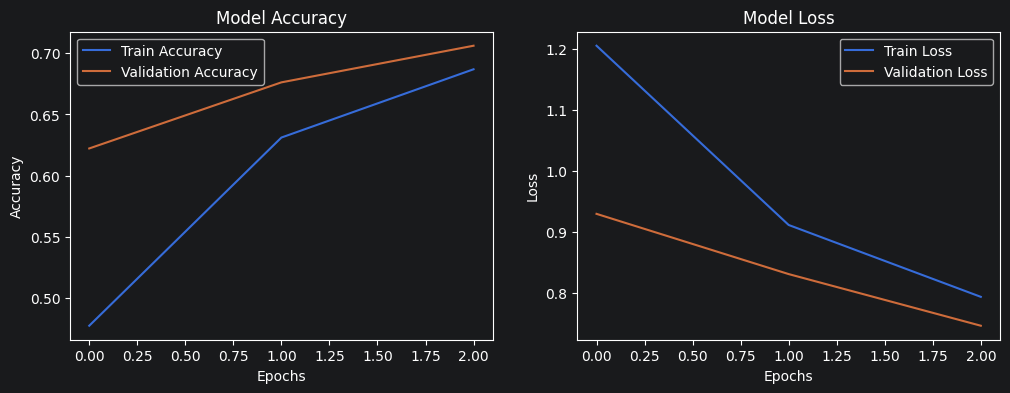

448/448 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step
Classification Report:

              precision    recall  f1-score   support

  Irrelevant       0.59      0.38      0.46      2529
    Negative       0.68      0.74      0.71      4383
     Neutral       0.65      0.51      0.58      3543
    Positive       0.56      0.74      0.64      3877

    accuracy                           0.62     14332
   macro avg       0.62      0.60      0.60     14332
weighted avg       0.63      0.62      0.61     14332



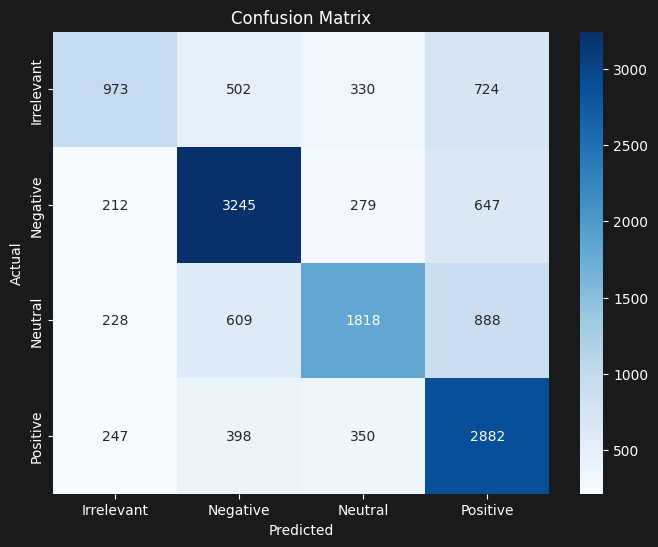

In [19]:
# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_improved.history['accuracy'], label='Train Accuracy')
plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_improved.history['loss'], label='Train Loss')
plt.plot(history_improved.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Predictions and Metrics
y_pred = improved_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("Classification Report:\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()